High-pass corner: 994.7 Hz
Low-pass corner:  99471.8 Hz


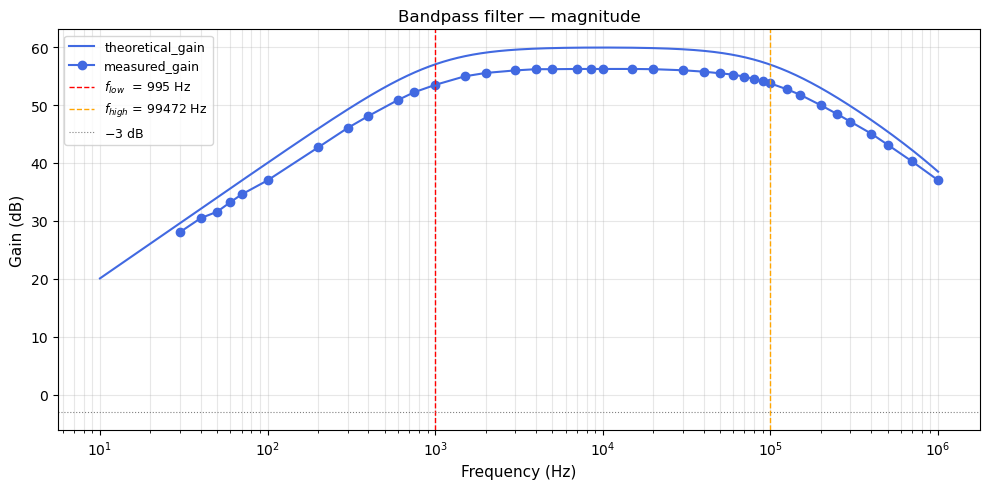

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



df = pd.read_csv("transfer.csv", index_col=0).T.reset_index()
df.columns = ["frequency_Hz", "gain", "input_mVpp", "output_Vpp"]
df["frequency_Hz"] = df["frequency_Hz"].astype(float)

measured_freq   = df["frequency_Hz"].values
measured_gain   =  df["output_Vpp"].values /( df["input_mVpp"].values / 1000)
measured_gain_dB = 20 * np.log10(measured_gain)

# ── Plot ──────────────────────────────────────────────────────────────────

# ── Component values — edit these ─────────────────────────────────────────
R1 = 1.6e3       # High-pass resistor [Ohm]
C1 = 100e-9    # High-pass capacitor [F]

R2 = 1.6e3       # Low-pass resistor [Ohm]
C2 = 1e-9     # Low-pass capacitor [F]

opamp_R1 = 10
opamp_R2 = 10e3
GBW = 1.6e9      # Op-amp gain-bandwidth product [Hz]
G = 1+ opamp_R2 / opamp_R1  # Op-amp gain
f_3dB = GBW / G  # Op-amp 3 dB frequency [Hz]
# ── Frequency axis ────────────────────────────────────────────────────────
f = np.logspace(1, 6, 5000)
w = 2 * np.pi * f

# ── Transfer function magnitude ───────────────────────────────────────────
H_HP = (1j * w * R1 * C1) / (1 + 1j * w * R1 * C1)
H_opmamp = np.abs(G / (1 + 1j * f / f_3dB))
H_LP = 1                  / (1 + 1j * w * R2 * C2)
H    = H_HP * H_LP * H_opmamp

theoretical_gain = 20 * np.log10(np.abs(H))

# ── Corner frequencies ────────────────────────────────────────────────────
f_low  = 1 / (2 * np.pi * R1 * C1)
f_high = 1 / (2 * np.pi * R2 * C2)

print(f"High-pass corner: {f_low:.1f} Hz")
print(f"Low-pass corner:  {f_high:.1f} Hz")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogx(f, theoretical_gain, label='theoretical_gain', lw=1.5, color='royalblue')
ax.semilogx(measured_freq, measured_gain_dB, label='measured_gain', marker='o', linestyle='-', color='royalblue')
ax.axvline(f_low,  color='red',    lw=1, ls='--', label=f'$f_{{low}}$  = {f_low:.0f} Hz')
ax.axvline(f_high, color='orange', lw=1, ls='--', label=f'$f_{{high}}$ = {f_high:.0f} Hz')
ax.axhline(-3,     color='grey',   lw=0.8, ls=':', label='$-$3 dB')
ax.set_ylabel("Gain (dB)", fontsize=11)
ax.set_xlabel("Frequency (Hz)", fontsize=11)
ax.set_title("Bandpass filter — magnitude", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#  fit transfer function of measured 


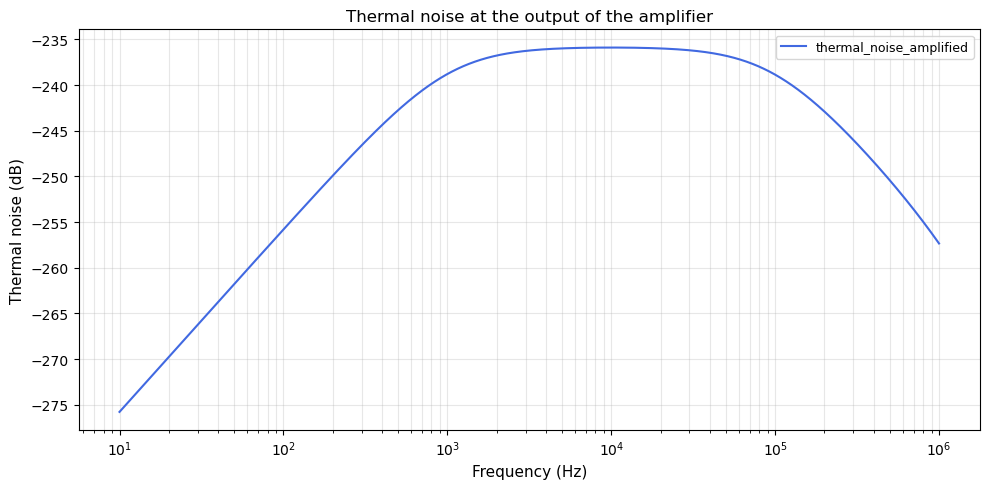

Total noise power at the output: 4.69e-07 W


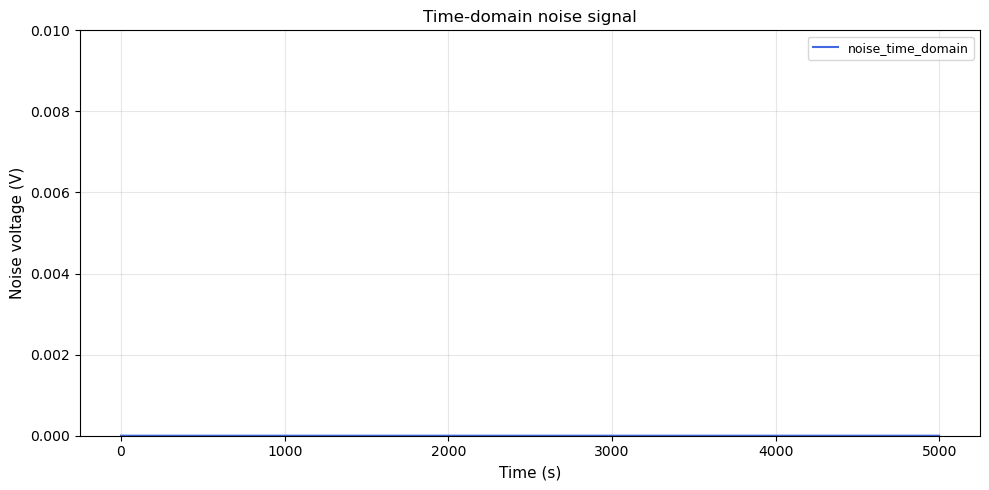

In [37]:
# What would the results of our white noise experiment look like theoretically:
R_thermal = 100e3
# make white thermal noise
T = 293
thermal_noise = 4 * 1.38e-23 * T * R_thermal

#Thermal noise at the output of the amplifier:
f = np.logspace(1, 6, 5000)
thermal_noise_amplified = thermal_noise * np.abs(H)
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(f, 20 * np.log10(thermal_noise_amplified), label='thermal_noise_amplified', lw=1.5, color='royalblue')
ax.set_ylabel("Thermal noise (dB)", fontsize=11)
ax.set_xlabel("Frequency (Hz)", fontsize=11)
ax.set_title("Thermal noise at the output of the amplifier", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()
# Integrate the noise over the bandwidth of the amplifier to get the total noise power:
noise_power = np.trapz(thermal_noise_amplified, f)
print(f"Total noise power at the output: {noise_power:.2e} W")
# IFFT the noise spectrum to get the time-domain noise signal:
noise_time_domain = np.fft.ifft(np.sqrt(thermal_noise_amplified))
# Plot the time-domain noise signal:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(noise_time_domain.real, label='noise_time_domain', lw=1.5, color='royalblue')
ax.set_ylabel("Noise voltage (V)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylim(-1e-6, 1e-2)
ax.set_title("Time-domain noise signal", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

